In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor


In [2]:
# Load data
df = pd.read_csv("healthcare_dataset.csv")
df

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55495,eLIZABeTH jaCkSOn,42,Female,O+,Asthma,2020-08-16,Joshua Jarvis,Jones-Thompson,Blue Cross,2650.714952,417,Elective,2020-09-15,Penicillin,Abnormal
55496,KYle pEREz,61,Female,AB-,Obesity,2020-01-23,Taylor Sullivan,Tucker-Moyer,Cigna,31457.797307,316,Elective,2020-02-01,Aspirin,Normal
55497,HEATher WaNG,38,Female,B+,Hypertension,2020-07-13,Joe Jacobs DVM,"and Mahoney Johnson Vasquez,",UnitedHealthcare,27620.764717,347,Urgent,2020-08-10,Ibuprofen,Abnormal
55498,JENniFER JOneS,43,Male,O-,Arthritis,2019-05-25,Kimberly Curry,"Jackson Todd and Castro,",Medicare,32451.092358,321,Elective,2019-05-31,Ibuprofen,Abnormal


In [3]:
# First five rows of dataset
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [4]:
#Last five rows of dataset
df.tail()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
55495,eLIZABeTH jaCkSOn,42,Female,O+,Asthma,2020-08-16,Joshua Jarvis,Jones-Thompson,Blue Cross,2650.714952,417,Elective,2020-09-15,Penicillin,Abnormal
55496,KYle pEREz,61,Female,AB-,Obesity,2020-01-23,Taylor Sullivan,Tucker-Moyer,Cigna,31457.797307,316,Elective,2020-02-01,Aspirin,Normal
55497,HEATher WaNG,38,Female,B+,Hypertension,2020-07-13,Joe Jacobs DVM,"and Mahoney Johnson Vasquez,",UnitedHealthcare,27620.764717,347,Urgent,2020-08-10,Ibuprofen,Abnormal
55498,JENniFER JOneS,43,Male,O-,Arthritis,2019-05-25,Kimberly Curry,"Jackson Todd and Castro,",Medicare,32451.092358,321,Elective,2019-05-31,Ibuprofen,Abnormal
55499,jAMES GARCiA,53,Female,O+,Arthritis,2024-04-02,Dennis Warren,Henry Sons and,Aetna,4010.134172,448,Urgent,2024-04-29,Ibuprofen,Abnormal


In [5]:
# Count of total rows and columns
df.shape

(55500, 15)

In [6]:
# Structure of dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  object 
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  object 
 3   Blood Type          55500 non-null  object 
 4   Medical Condition   55500 non-null  object 
 5   Date of Admission   55500 non-null  object 
 6   Doctor              55500 non-null  object 
 7   Hospital            55500 non-null  object 
 8   Insurance Provider  55500 non-null  object 
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  object 
 12  Discharge Date      55500 non-null  object 
 13  Medication          55500 non-null  object 
 14  Test Results        55500 non-null  object 
dtypes: float64(1), int64(2), object(12)
memory usage: 3.8

In [7]:
# Statistic summary of dataset
df.describe()

,Age,Billing Amount,Room Number
count,55500.000000,55500.000000,55500.000000
mean,51.539459,25539.316097,301.134829
std,19.602454,14211.454431,115.243069
min,13.000000,-2008.492140,101.000000
25%,35.000000,13241.224652,202.000000
50%,52.000000,25538.069376,302.000000
75%,68.000000,37820.508436,401.000000
max,89.000000,52764.276736,500.000000


In [9]:
# Column names
df.columns

Index(['Name', 'Age', 'Gender', 'Blood Type', 'Medical Condition',
       'Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider',
       'Billing Amount', 'Room Number', 'Admission Type', 'Discharge Date',
       'Medication', 'Test Results'],
      dtype='object')

In [10]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)
df.columns

Index(['name', 'age', 'gender', 'blood_type', 'medical_condition',
       'date_of_admission', 'doctor', 'hospital', 'insurance_provider',
       'billing_amount', 'room_number', 'admission_type', 'discharge_date',
       'medication', 'test_results'],
      dtype='object')

In [11]:
#Data Types
print(df.dtypes)

name                   object
age                     int64
gender                 object
blood_type             object
medical_condition      object
date_of_admission      object
doctor                 object
hospital               object
insurance_provider     object
billing_amount        float64
room_number             int64
admission_type         object
discharge_date         object
medication             object
test_results           object
dtype: object


In [12]:
# Check null values 
df.isnull().sum()

name                  0
age                   0
gender                0
blood_type            0
medical_condition     0
date_of_admission     0
doctor                0
hospital              0
insurance_provider    0
billing_amount        0
room_number           0
admission_type        0
discharge_date        0
medication            0
test_results          0
dtype: int64

In [13]:
# check duplicates 
df.duplicated().sum()

np.int64(534)

In [15]:
# Drop duplicates 
df = df.drop_duplicates()
print(f"After dropping duplicates,count: {df.duplicated().sum()}")

After dropping duplicates,count: 0


In [24]:
# Univarient Analysis

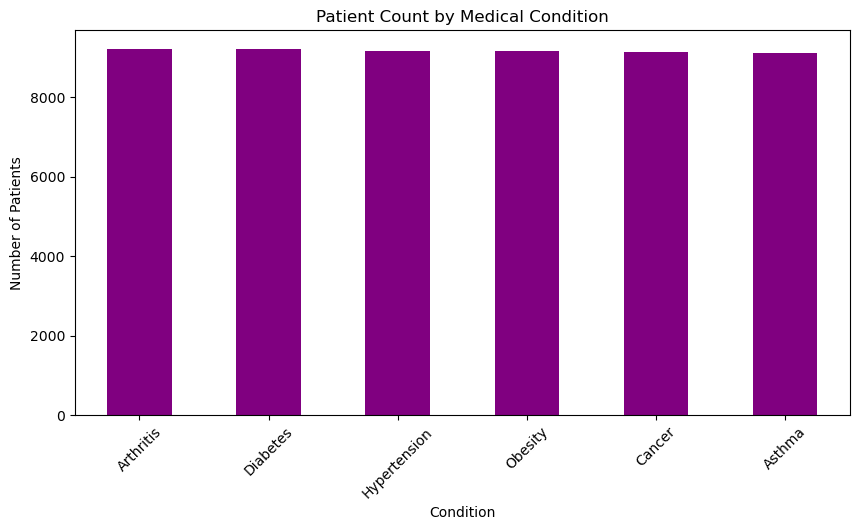

In [18]:
# Patients count
plt.figure(figsize=(10, 5))
df['medical_condition'].value_counts().plot(kind='bar', color='purple')
plt.title('Patient Count by Medical Condition')
plt.xlabel('Condition')
plt.ylabel('Number of Patients')
plt.xticks(rotation=45)
plt.show()

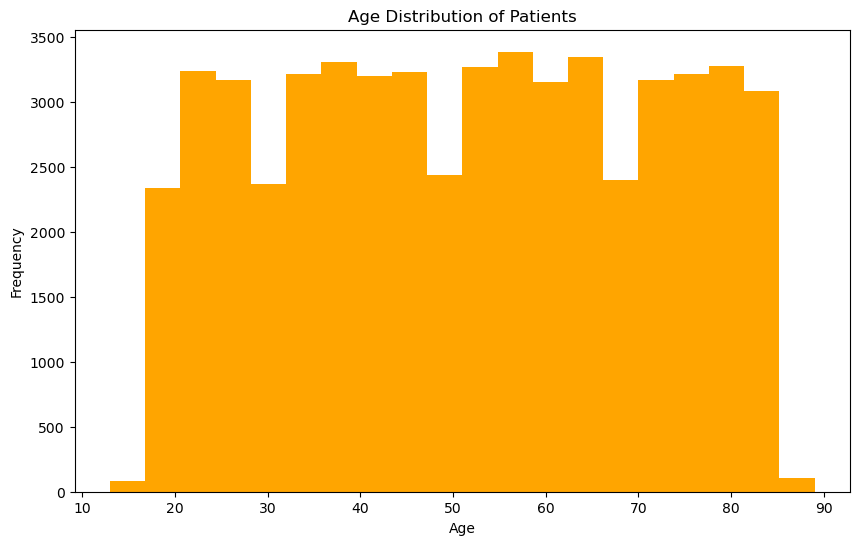

In [19]:
# Age distribution of patients
plt.figure(figsize=(10, 6))
plt.hist(df['age'], bins=20, color='orange')
plt.title('Age Distribution of Patients')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

In [25]:
# Bivariate Analysis

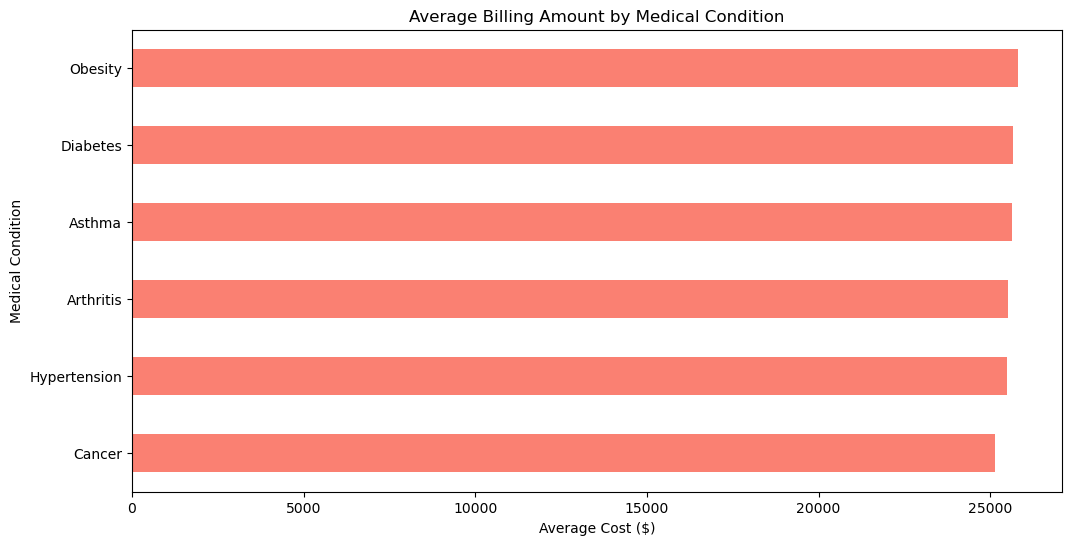

In [26]:
# Compare average billing amount across different medical conditions
plt.figure(figsize=(12, 6))
df.groupby('medical_condition')['billing_amount'].mean().sort_values().plot(kind='barh', color='salmon')
plt.title('Average Billing Amount by Medical Condition')
plt.xlabel('Average Cost ($)')
plt.ylabel('Medical Condition')
plt.show()

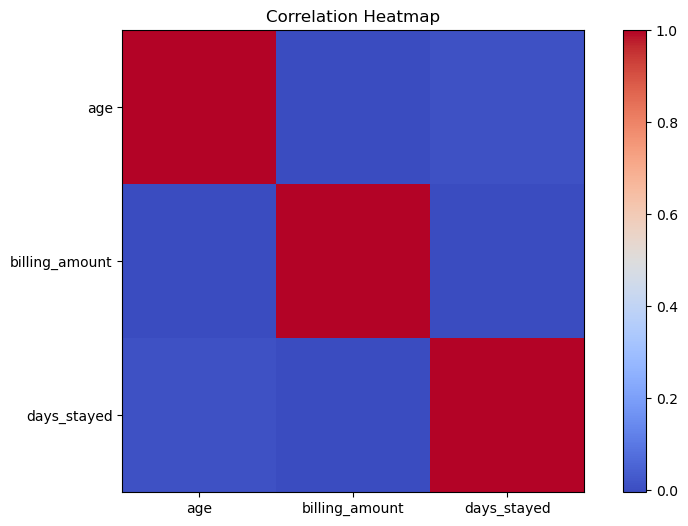

In [27]:
# Correlation Heatmap
plt.figure(figsize=(10, 6))
numeric_cols = df[['age', 'billing_amount', 'days_stayed']]
sns_corr = numeric_cols.corr()
plt.imshow(sns_corr, cmap='coolwarm', interpolation='none')
plt.colorbar()
plt.xticks(range(len(sns_corr)), sns_corr.columns)
plt.yticks(range(len(sns_corr)), sns_corr.columns)
plt.title('Correlation Heatmap')
plt.show()

In [35]:
# Feature Engineering 
df = df.copy()
# Convert the date columns to datetime
df['date_of_admission'] = pd.to_datetime(df['date_of_admission'])
df['discharge_date'] = pd.to_datetime(df['discharge_date'])
# number of days stayed
df['days_stayed'] = (df['discharge_date'] - df['date_of_admission']).dt.days
print(f"Minimum days stayed: {df['days_stayed'].min()}")
print(f"Maximum days stayed: {df['days_stayed'].max()}")

Minimum days stayed: 1
Maximum days stayed: 30


In [36]:
# Calculate cost per day (make a new column)
df['cost_per_day'] = df['billing_amount'] / (df['days_stayed'] + 1)
df.head()

,name,age,gender,blood_type,medical_condition,date_of_admission,doctor,hospital,insurance_provider,billing_amount,room_number,admission_type,discharge_date,medication,test_results,days_stayed,cost_per_day
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal,2,6285.427102
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive,6,4806.189612
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal,15,1747.193505
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal,30,1222.896207
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal,20,678.015134


In [39]:
df_model = df.copy()
df_model['medical_condition_code'] = df_model['medical_condition'].astype('category').cat.codes
df_model['admission_type_code'] = df_model['admission_type'].astype('category').cat.codes
df_model['gender_code'] = df_model['gender'].astype('category').cat.codes

In [40]:
# Features and Target
features = ['age', 'medical_condition_code', 'admission_type_code', 'gender_code', 'days_stayed']
X = df_model[features]
y = df_model['billing_amount']
# Train and test the model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Model is ready!")

Model is ready!


In [41]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Training Complete!")

Training Complete!


In [42]:
from sklearn.metrics import mean_absolute_error, r2_score
# Calculate error
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: {mae:.2f}")

Mean Absolute Error: 13397.47


In [44]:
# Outliers detection
X_outliers = df_model[['days_stayed', 'billing_amount']]
iso_forest = IsolationForest(contamination=0.05, random_state=42)
# Predict: 1 = Normal, -1 = Outlier
df_model['anomaly_score'] = iso_forest.fit_predict(X_outliers)
print(df_model['anomaly_score'].value_counts())

anomaly_score
 1    52218
-1     2748
Name: count, dtype: int64


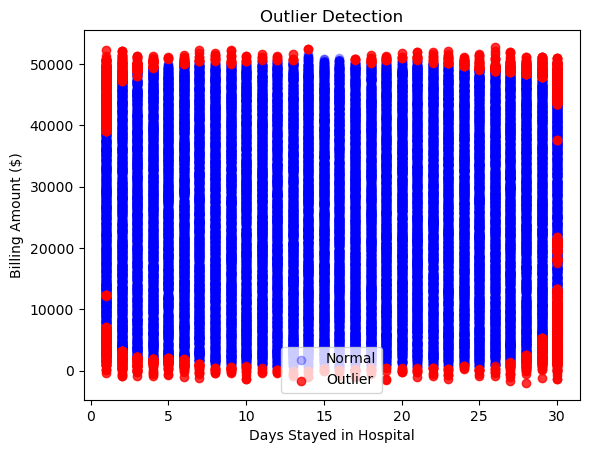

In [45]:
# Plot for Normal and Outliers Detection 
normal = df_model[df_model['anomaly_score'] == 1]
outliers = df_model[df_model['anomaly_score'] == -1]
# Normal
plt.scatter(normal['days_stayed'], normal['billing_amount'], color='blue', label='Normal', alpha=0.3)

# Outliers
plt.scatter(outliers['days_stayed'], outliers['billing_amount'], color='red', label='Outlier', alpha=0.8)
plt.title('Outlier Detection')
plt.xlabel('Days Stayed in Hospital')
plt.ylabel('Billing Amount ($)')
plt.legend()
plt.show()

In [ ]:
df.to_csv("Healthcare_Dataset_Cleaned.csv", index = False)